# 2015 vs 2025: SEBI Investor Survey Comparison
Tracks how participation, instrument choice, awareness, barriers, and information behaviour shifted over a decade.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

DATA = Path("..") / "data" / "sebi"
D25  = DATA / "2025"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

BLUE15 = "#2563EB"
ORG25  = "#EA580C"

## 1. Participation Rate by Education Level

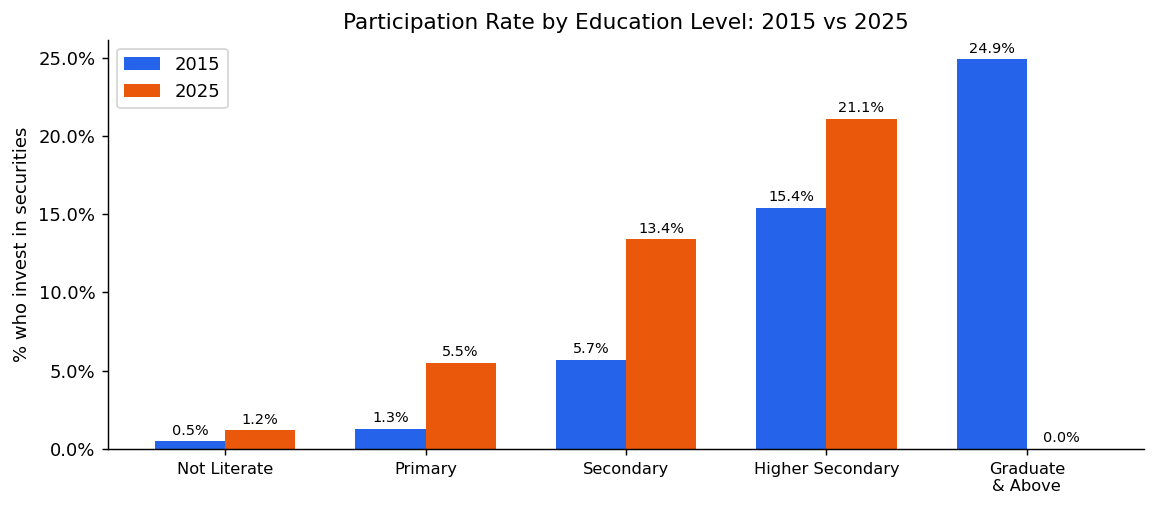

         education  2015 %  2025 %  change pp
      Not Literate     0.5     1.2        0.7
           Primary     1.3     5.5        4.2
         Secondary     5.7    13.4        7.7
  Higher Secondary    15.4    21.1        5.7
Graduate and Above    24.9     0.0      -24.9


In [2]:
ep15 = pd.read_csv(DATA / "education_participation.csv")
ep25 = pd.read_csv(D25 / "education_participation_2025.csv")

edu_order = ["Not Literate", "Primary", "Secondary", "Higher Secondary", "Graduate and Above"]
ep15 = ep15.set_index("education_level").reindex(edu_order)
ep25 = ep25.set_index("education_level").reindex(edu_order)

x = np.arange(len(edu_order))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, ep15["pct_who_invest"], w, label="2015", color=BLUE15)
b2 = ax.bar(x + w/2, ep25["pct_who_invest"], w, label="2025", color=ORG25)
ax.set_xticks(x)
ax.set_xticklabels([e.replace(" and ", "\n& ") for e in edu_order], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("% who invest in securities")
ax.set_title("Participation Rate by Education Level: 2015 vs 2025")
ax.legend()
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

cmp = pd.DataFrame({"education": edu_order,
                    "2015 %": ep15["pct_who_invest"].values,
                    "2025 %": ep25["pct_who_invest"].values})
cmp["change pp"] = (cmp["2025 %"] - cmp["2015 %"]).round(1)
print(cmp.to_string(index=False))

## 2. Instrument Choice by Education Level

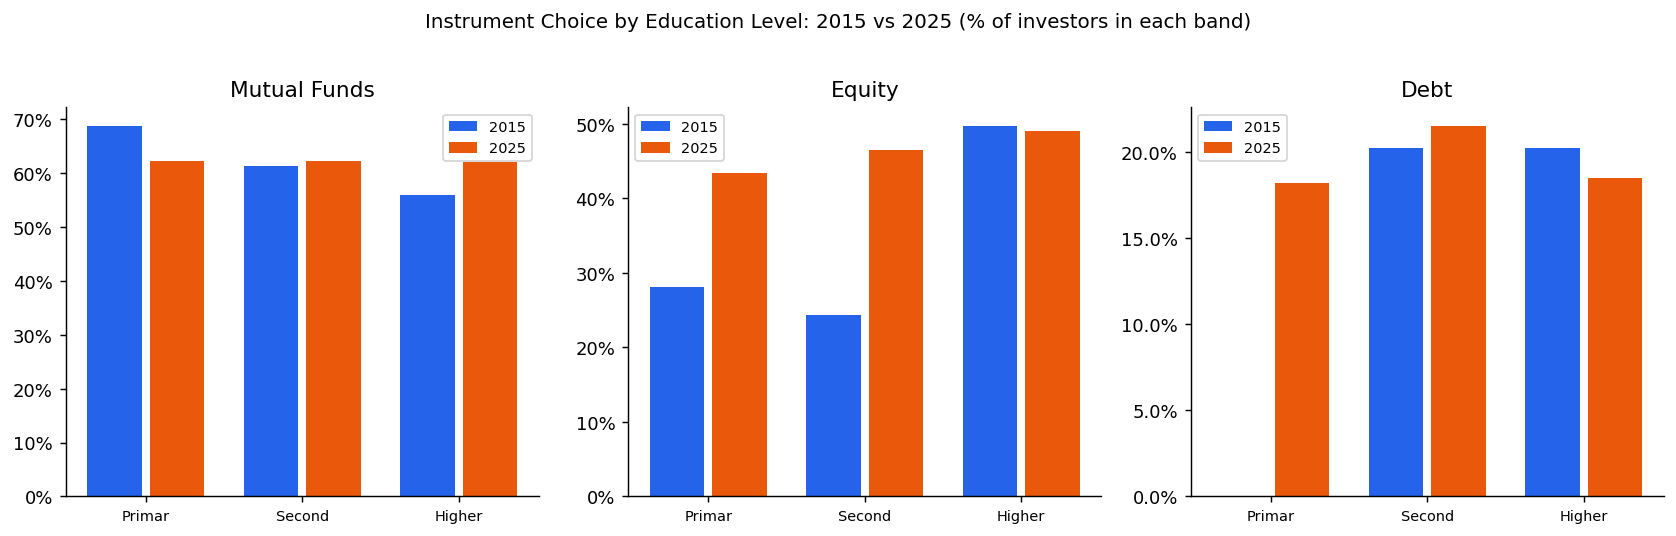

In [3]:
ei15 = pd.read_csv(DATA / "education_instrument_choice.csv")
ei25 = pd.read_csv(D25 / "education_instrument_choice_2025.csv")

common_edu = sorted(set(ei15["education_level"]) & set(ei25["education_level"]),
                    key=lambda e: edu_order.index(e))

ei15 = ei15.set_index("education_level").reindex(common_edu)
ei25 = ei25.set_index("education_level").reindex(common_edu)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
instruments = [("mf_pct", "Mutual Funds"), ("equity_pct", "Equity"), ("debt_pct", "Debt")]
for ax, (col, title) in zip(axes, instruments):
    x = np.arange(len(common_edu))
    ax.bar(x - 0.2, ei15[col], 0.35, label="2015", color=BLUE15)
    ax.bar(x + 0.2, ei25[col], 0.35, label="2025", color=ORG25)
    ax.set_xticks(x)
    ax.set_xticklabels([e[:6] for e in common_edu], fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("Instrument Choice by Education Level: 2015 vs 2025 (% of investors in each band)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Instrument Choice by Income Band

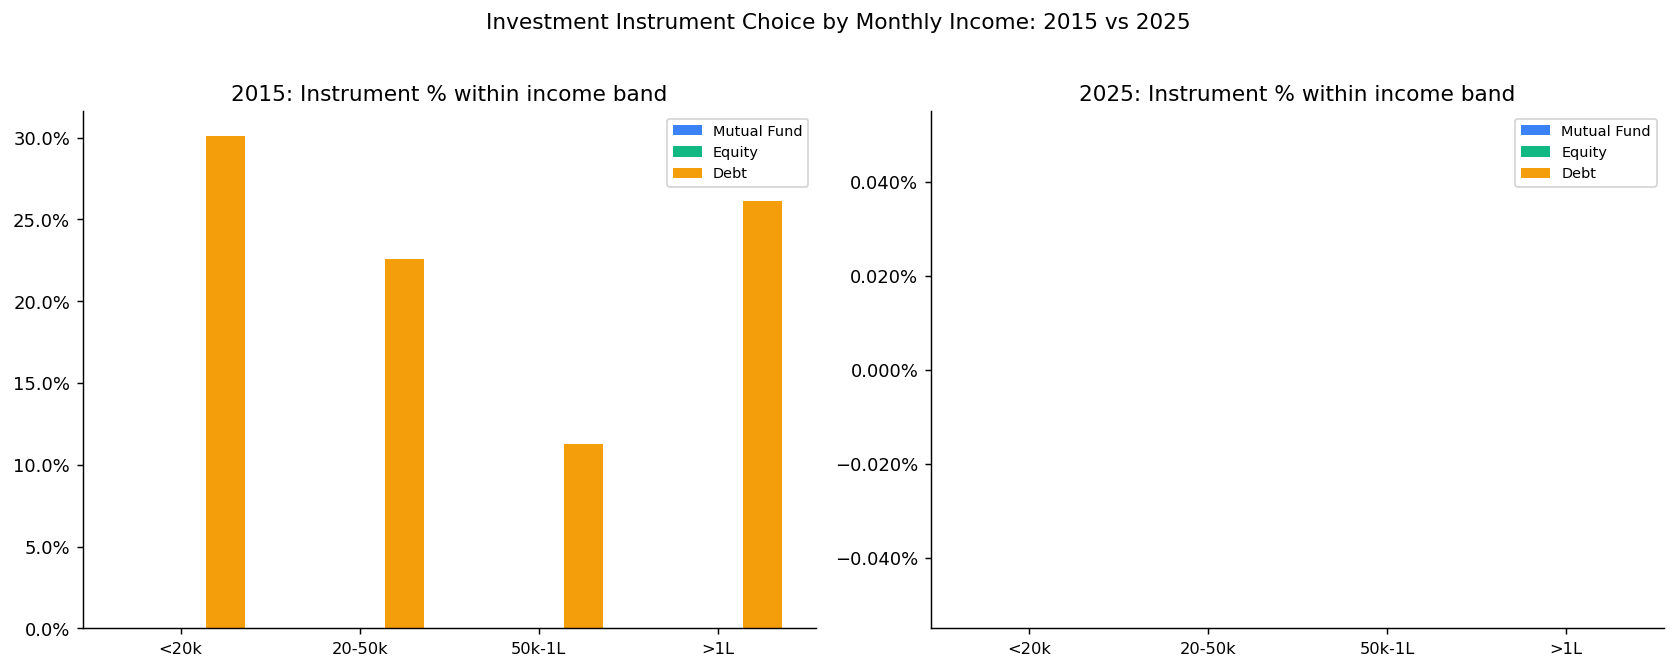

In [4]:
inc15 = pd.read_csv(DATA / "05_urban_investment_instrument_choice_by_income.csv")
inc25 = pd.read_csv(D25 / "05_income_instrument_2025.csv")

# Standardise 2015 columns
inc15.columns = [c.lower().strip() for c in inc15.columns]
inc15 = inc15.rename(columns={
    "type of investors": "investor_type",
    "income range": "income_range",
    "percentage to total investors (uom:%(percentage)), scaling factor:1": "pct_of_total",
})
inc15 = inc15[inc15["investor_type"] != "Total Respondents"]

bands = ["Less than 20,000", "20,000 to 50,000", "50,000 to 1 lakh", "Above 1 lakh"]
inv_types = ["Mutual Fund Investor", "Equity Investor", "Debt Investor"]
colors = {"Mutual Fund Investor": "#3B82F6", "Equity Investor": "#10B981", "Debt Investor": "#F59E0B"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (year_df, year_label) in zip(axes, [(inc15, "2015"), (inc25, "2025")]):
    x = np.arange(len(bands))
    for i, itype in enumerate(inv_types):
        sub = year_df[year_df["investor_type"] == itype].set_index("income_range")
        vals = [sub.loc[b, "pct_of_total"] if b in sub.index else 0 for b in bands]
        ax.bar(x + (i-1)*0.25, vals, 0.22, label=itype.replace(" Investor",""),
               color=list(colors.values())[i])
    ax.set_xticks(x)
    ax.set_xticklabels(["<20k", "20-50k", "50k-1L", ">1L"], fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"{year_label}: Instrument % within income band")
    ax.legend(fontsize=8)
plt.suptitle("Investment Instrument Choice by Monthly Income: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

## 4. Occupation: Investor Rate (Top/Bottom)

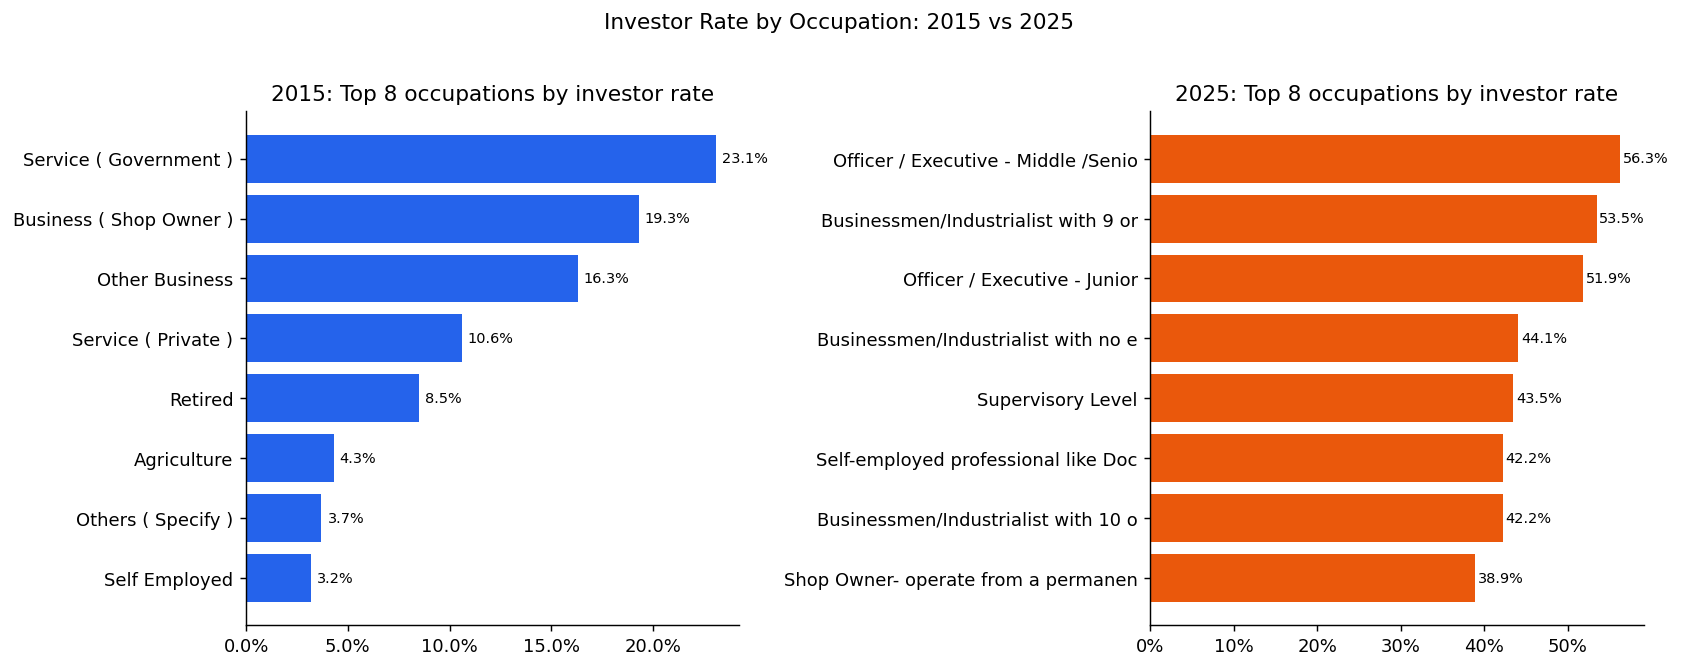

In [5]:
occ15 = pd.read_csv(DATA / "14_urban_investors_by_occupation.csv")
occ25 = pd.read_csv(D25 / "14_occupation_2025.csv")

occ15.columns = [c.lower().strip() for c in occ15.columns]
occ15 = occ15.rename(columns={
    "occupation": "occupation",
    "percentage of urban investors (uom:%(percentage)), scaling factor:1": "pct_investor"
})
occ15 = occ15[occ15["occupation"] != "Total"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (df, yr) in zip(axes, [(occ15, "2015"), (occ25, "2025")]):
    top = df.nlargest(8, "pct_investor")[["occupation","pct_investor"]].iloc[::-1]
    labels = [o[:35] for o in top["occupation"]]
    ax.barh(labels, top["pct_investor"], color=BLUE15 if yr=="2015" else ORG25)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"{yr}: Top 8 occupations by investor rate")
    for i, v in enumerate(top["pct_investor"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
plt.suptitle("Investor Rate by Occupation: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

## 5. Product Awareness

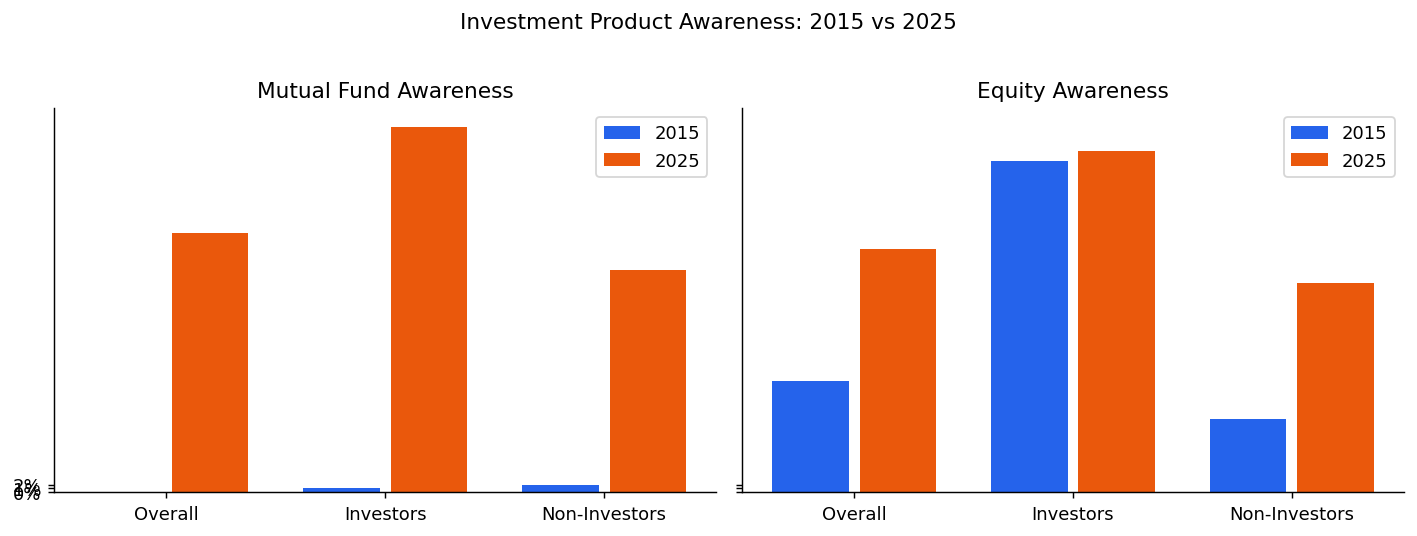

MF Awareness (overall): Awareness → 66.1 %
Equity Awareness (overall): 28.4 → 62.0 %


In [6]:
aw15 = pd.read_csv(DATA / "15_urban_household_awareness_investment_instruments.csv")
aw25 = pd.read_csv(D25 / "15_awareness_2025.csv")

# 2015: overall awareness row
aw15.columns = [c.lower() for c in aw15.columns]
aw15_overall = aw15[aw15["awareness of investment instruments"] == "Awareness"].iloc[0]
aw15_inv     = aw15[aw15["awareness of investment instruments"] == "Investor Awareness"].iloc[0]
aw15_noninv  = aw15[aw15["awareness of investment instruments"] == "Non - Investor Awareness"].iloc[0]

# 2025 column names (truncated by build script)
aw25_overall = aw25[aw25["group"] == "Awareness"].iloc[0]
aw25_inv     = aw25[aw25["group"] == "Investor Awareness"].iloc[0]
aw25_noninv  = aw25[aw25["group"] == "Non - Investor Awareness"].iloc[0]

groups = ["Overall", "Investors", "Non-Investors"]
mf_15  = [aw15_overall.iloc[2], aw15_inv.iloc[2], aw15_noninv.iloc[2]]
eq_15  = [aw15_overall.iloc[3], aw15_inv.iloc[3], aw15_noninv.iloc[3]]
mf_25  = [aw25_overall["mutual_f"], aw25_inv["mutual_f"], aw25_noninv["mutual_f"]]
eq_25  = [aw25_overall["stocks__"], aw25_inv["stocks__"], aw25_noninv["stocks__"]]

x = np.arange(len(groups))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (v15, v25, title) in zip(axes, [
    (mf_15, mf_25, "Mutual Fund Awareness"),
    (eq_15, eq_25, "Equity Awareness"),
]):
    ax.bar(x - 0.2, v15, 0.35, label="2015", color=BLUE15)
    ax.bar(x + 0.2, v25, 0.35, label="2025", color=ORG25)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title)
    ax.legend()
plt.suptitle("Investment Product Awareness: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

print("MF Awareness (overall):", mf_15[0], "→", mf_25[0], "%")
print("Equity Awareness (overall):", eq_15[0], "→", eq_25[0], "%")

## 6. Barriers to Investing

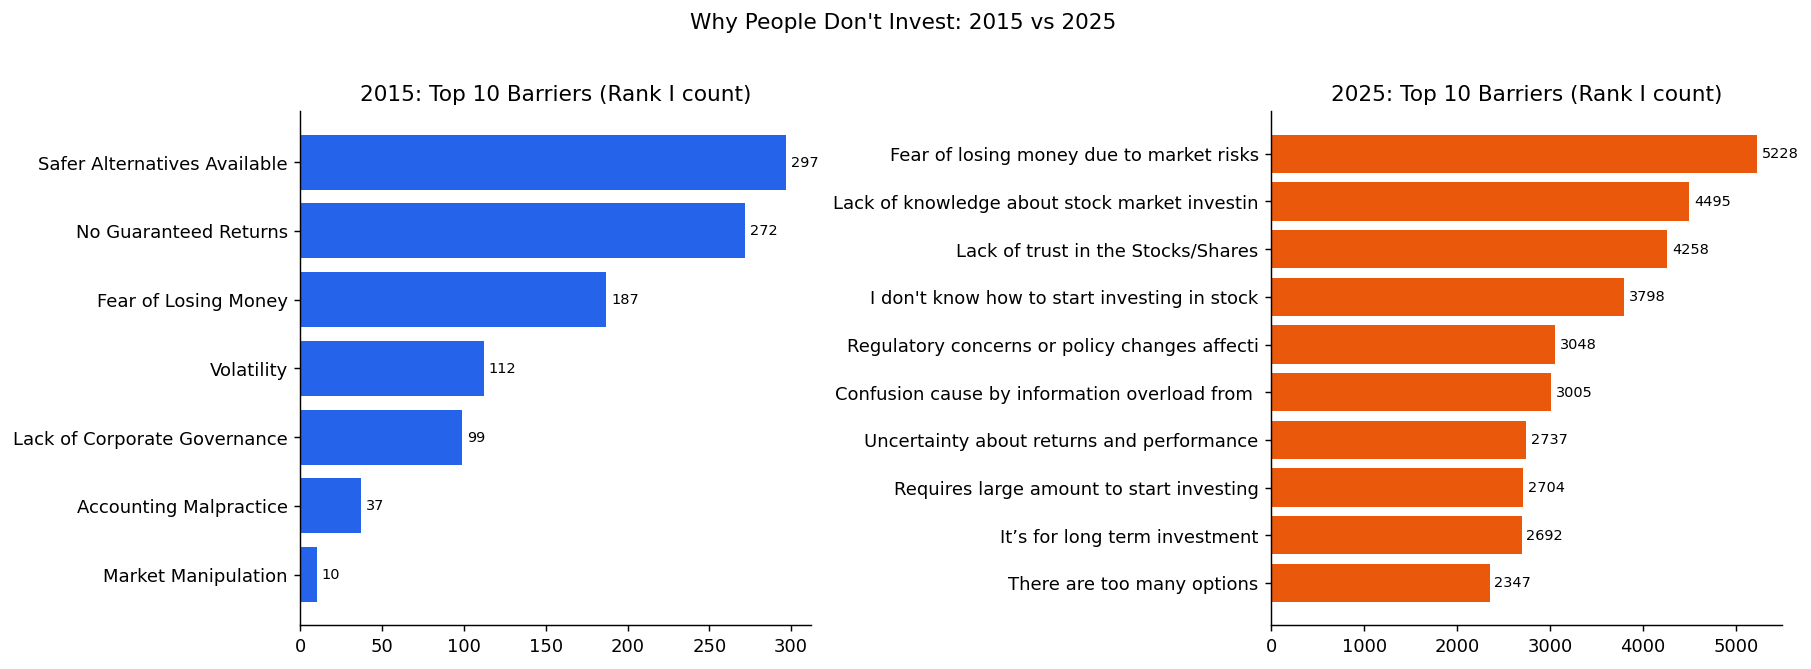

In [7]:
bar15 = pd.read_csv(DATA / "10_reasons_for_low_participation_securities_markets.csv")
bar25 = pd.read_csv(D25 / "10_barriers_2025.csv")

bar15.columns = [c.lower() for c in bar15.columns]
bar15_r1 = bar15[bar15["rank"] == "Rank I"].copy()
bar15_r1 = bar15_r1.rename(columns={"reasons for low participation": "reason",
                                     bar15_r1.columns[-1]: "n"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, yr) in zip(axes, [(bar15_r1, "2015"), (bar25, "2025")]):
    top = df.nlargest(10, "n")[["reason","n"]].iloc[::-1]
    labels = [r[:45] for r in top["reason"]]
    ax.barh(labels, top["n"], color=BLUE15 if yr=="2015" else ORG25)
    ax.set_title(f"{yr}: Top 10 Barriers (Rank I count)")
    for i, v in enumerate(top["n"]):
        ax.text(v + max(top["n"])*0.01, i, str(v), va="center", fontsize=8)
plt.suptitle("Why People Don't Invest: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

## 7. Motivations to Invest

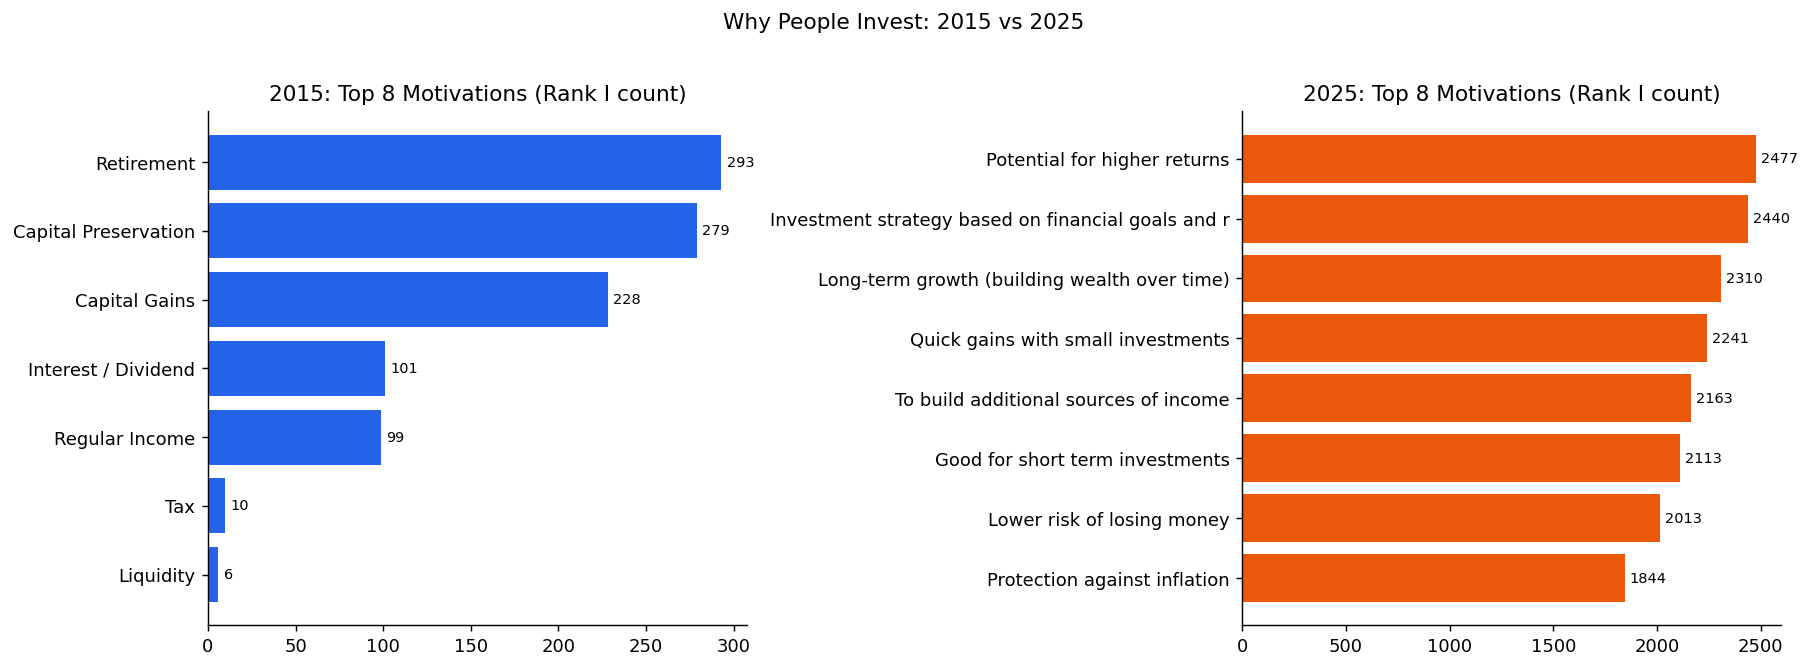

In [8]:
mot15 = pd.read_csv(DATA / "09_reasons_for_clients_to_invest_securities_markets.csv")
mot25 = pd.read_csv(D25 / "09_motivations_2025.csv")

mot15.columns = [c.lower() for c in mot15.columns]
mot15_r1 = mot15[mot15["rank"] == "Rank I"].copy()
mot15_r1 = mot15_r1.rename(columns={"reasons for clients to invest in securities markets": "reason",
                                     mot15_r1.columns[-1]: "n"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, yr) in zip(axes, [(mot15_r1, "2015"), (mot25, "2025")]):
    top = df.nlargest(8, "n")[["reason","n"]].iloc[::-1]
    labels = [r[:50] for r in top["reason"]]
    ax.barh(labels, top["n"], color=BLUE15 if yr=="2015" else ORG25)
    ax.set_title(f"{yr}: Top 8 Motivations (Rank I count)")
    for i, v in enumerate(top["n"]):
        ax.text(v + max(top["n"])*0.01, i, str(v), va="center", fontsize=8)
plt.suptitle("Why People Invest: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

## 8. Information Sources

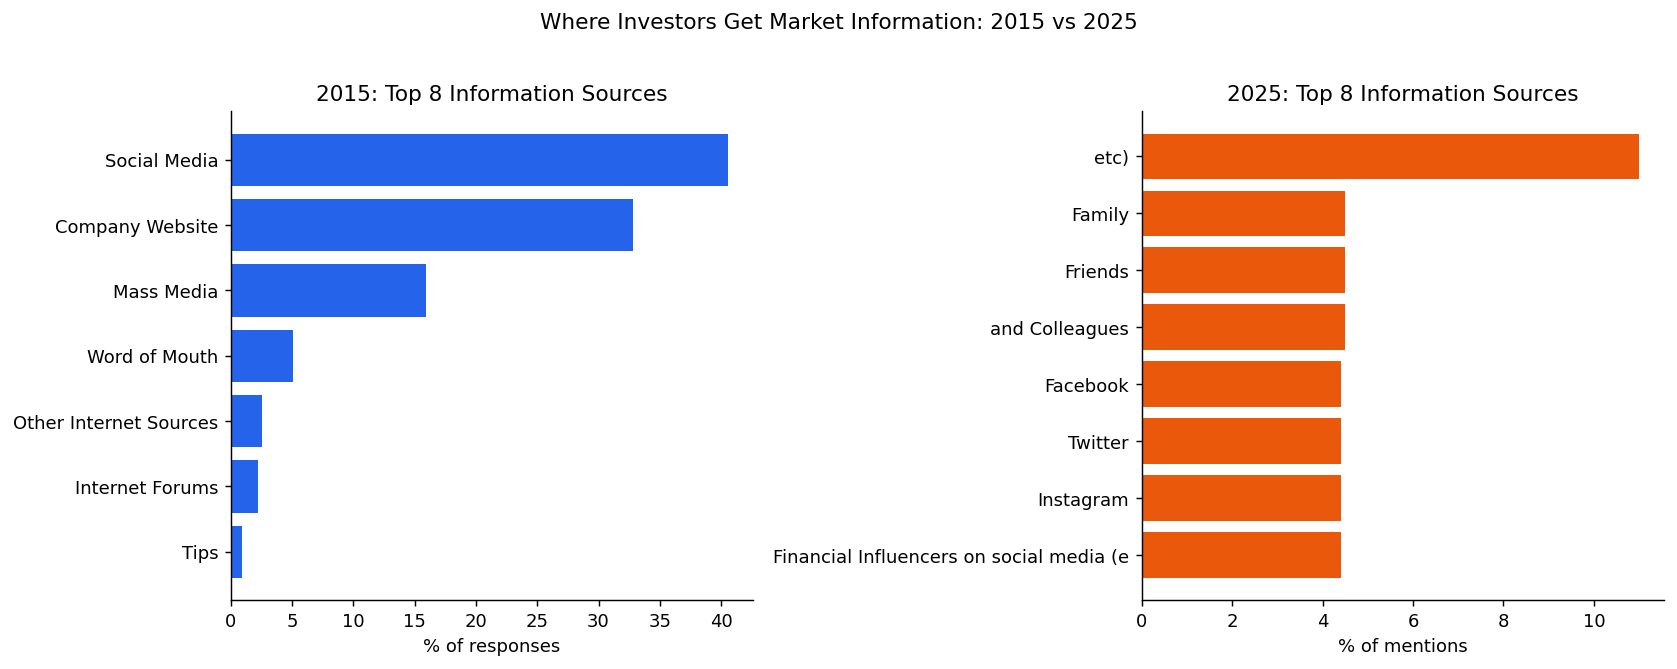

In [9]:
src15 = pd.read_csv(DATA / "06_information_sources_market_participants.csv")
src25 = pd.read_csv(D25 / "06_info_sources_2025.csv")

src15.columns = [c.lower() for c in src15.columns]
src15_r1 = src15[src15["rank"] == "Rank I"].copy()
src15_r1 = src15_r1.rename(columns={"information source": "source",
                                     src15_r1.columns[-1]: "pct"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (df, yr, col) in zip(axes, [
    (src15_r1, "2015", "pct"),
    (src25,    "2025", "pct"),
]):
    top = df.nlargest(8, col)[["source", col]].iloc[::-1]
    labels = [s[:40] for s in top["source"]]
    ax.barh(labels, top[col], color=BLUE15 if yr=="2015" else ORG25)
    ax.set_title(f"{yr}: Top 8 Information Sources")
    suffix = "% of responses" if yr=="2015" else "% of mentions"
    ax.set_xlabel(suffix)
plt.suptitle("Where Investors Get Market Information: 2015 vs 2025", y=1.02)
plt.tight_layout()
plt.show()

## 9. Investor Education Programme (IEP) Participation

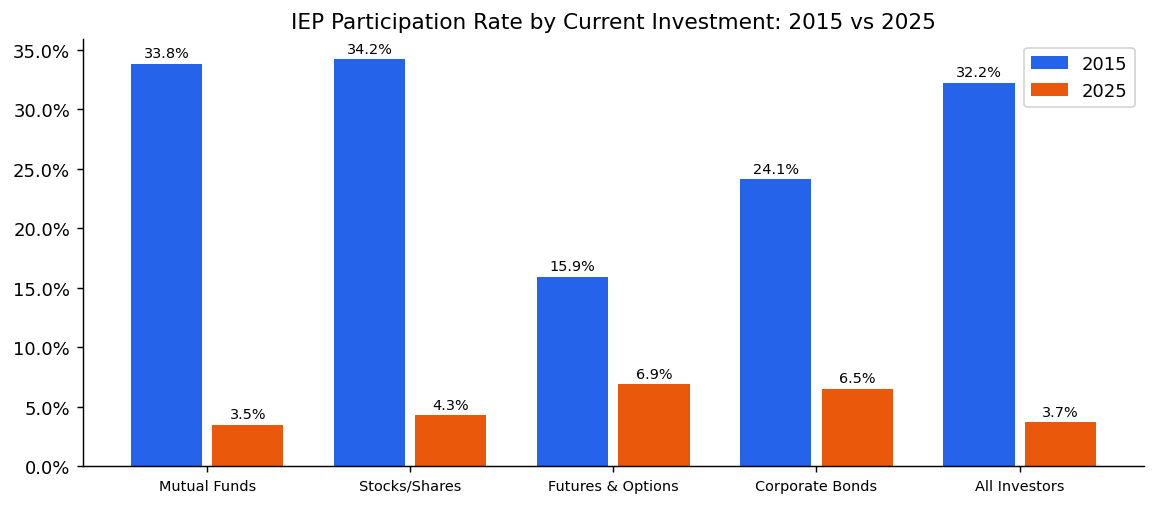

Note: IEP = Investor Education Programmes run by SEBI, NISM, exchanges, depositories, AMFI etc.


In [10]:
iep15 = pd.read_csv(DATA / "11_investor_education_program_participation_tabulation.csv")
iep25 = pd.read_csv(D25 / "11_iep_2025.csv")

iep15.columns = [c.lower() for c in iep15.columns]
iep15 = iep15.rename(columns={"current investment": "investment",
                               "percentage of participant investors (uom:%(percentage)), scaling factor:1": "pct_part"})

# Align instrument labels
label_map_15 = {"Mutual Funds": "Mutual Funds", "Equities": "Stocks / Shares",
                "Derivatives": "Futures & Options", "Debentures": "Corporate Bonds",
                "All Investors": "All Investors"}
iep15["investment"] = iep15["investment"].map(label_map_15)
iep15 = iep15.dropna(subset=["investment"])

common = ["Mutual Funds", "Stocks / Shares", "Futures & Options", "Corporate Bonds", "All Investors"]
p15 = iep15.set_index("investment").reindex(common)["pct_part"]
p25 = iep25.set_index("investment").reindex(common)["pct_part"]

x = np.arange(len(common))
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - 0.2, p15, 0.35, label="2015", color=BLUE15)
b2 = ax.bar(x + 0.2, p25, 0.35, label="2025", color=ORG25)
ax.set_xticks(x)
ax.set_xticklabels([c.replace(" / ","/") for c in common], fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("IEP Participation Rate by Current Investment: 2015 vs 2025")
ax.legend()
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()
print("Note: IEP = Investor Education Programmes run by SEBI, NISM, exchanges, depositories, AMFI etc.")

## 10. Holding Duration — Equity

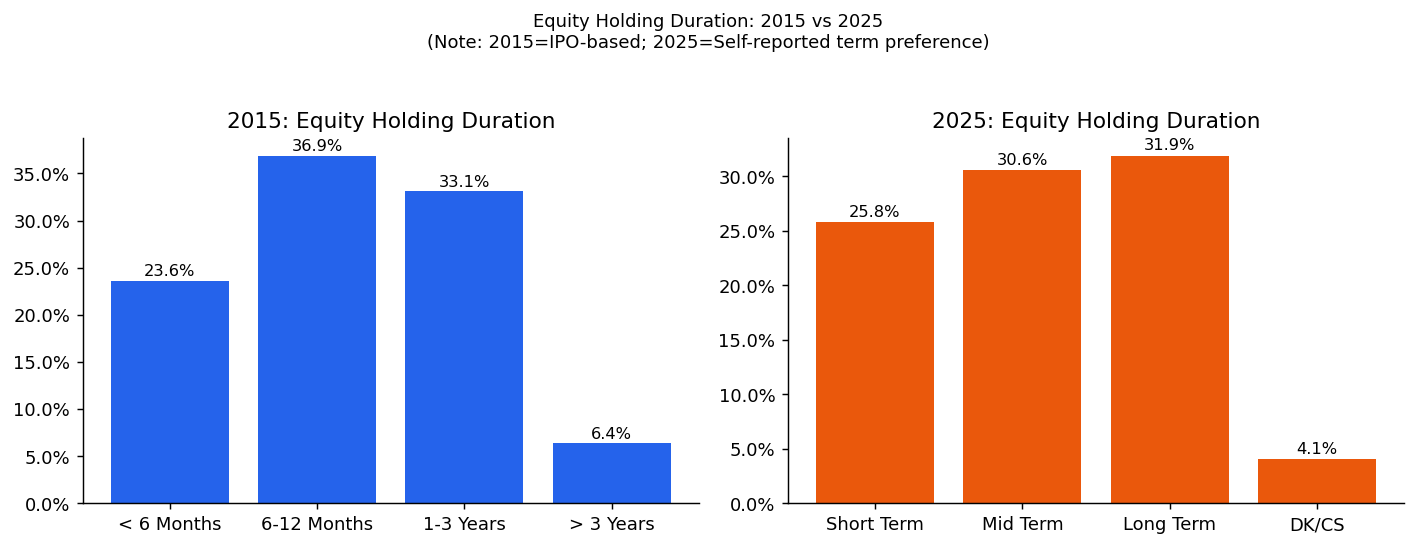

In [11]:
hd15 = pd.read_csv(DATA / "16_holding_period_equities_purchased_via_ipo.csv")
hd25 = pd.read_csv(D25 / "16_equity_holding_2025.csv")

hd15.columns = [c.lower() for c in hd15.columns]
hd15 = hd15.rename(columns={"holding period": "period",
                             "percent (uom:%(percentage)), scaling factor:1": "pct"})

# 2015 categories
order15 = ["< 6 Months", "6-12 Months", "1-3 Years", "> 3 Years"]
p15 = hd15.set_index("period").reindex(order15)["pct"]

# 2025 categories (Short/Mid/Long term after fix)
hd25_clean = hd25.groupby("period")["n"].sum().reset_index()
hd25_clean["pct"] = (hd25_clean["n"] / hd25_clean["n"].sum() * 100).round(1)
order25 = ["Short Term", "Mid Term", "Long Term", "DK/CS"]
p25 = hd25_clean.set_index("period").reindex([o for o in order25 if o in hd25_clean["period"].values])["pct"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(order15, p15, color=BLUE15)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("2015: Equity Holding Duration")
for i, v in enumerate(p15):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

axes[1].bar(p25.index, p25, color=ORG25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("2025: Equity Holding Duration")
for i, v in enumerate(p25):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Equity Holding Duration: 2015 vs 2025\n(Note: 2015=IPO-based; 2025=Self-reported term preference)",
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

## 11. Holding Duration — Mutual Funds

In [12]:
mf15 = pd.read_csv(DATA / "18_mutual_fund_holding_duration.csv")
mf25 = pd.read_csv(D25 / "18_mf_holding_2025.csv")

mf15.columns = [c.lower() for c in mf15.columns]
mf15 = mf15.rename(columns={
    "mutual funds (mf) holding duration": "period",
    mf15.columns[3]: "pct"
})

if mf25.empty or len(mf25) == 0:
    print("18_mf_holding_2025.csv is empty — run src/fix_sebi_2025.py first")
else:
    mf25_clean = mf25.groupby("period")["n"].sum().reset_index()
    mf25_clean["pct"] = (mf25_clean["n"] / mf25_clean["n"].sum() * 100).round(1)

    order15_mf = ["< 6 Months", "6–12 months", "1–3 Years", "> 3 Years"]
    p15_mf = mf15.set_index("period").reindex(order15_mf)["pct"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(range(len(order15_mf)), p15_mf, color=BLUE15, tick_label=order15_mf)
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].set_title("2015: MF Holding Duration")
    for i, v in enumerate(p15_mf):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

    axes[1].bar(mf25_clean["period"], mf25_clean["pct"], color=ORG25)
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1].set_title("2025: MF Holding Duration")
    for i, v in enumerate(mf25_clean["pct"]):
        axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

    plt.suptitle("Mutual Fund Holding Duration: 2015 vs 2025", fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

18_mf_holding_2025.csv is empty — run src/fix_sebi_2025.py first


## 12. Summary Dashboard

In [13]:
summary = pd.DataFrame([
    {"Metric": "Overall MF awareness",         "2015": "28.4%",  "2025": "66.1%",  "Direction": "↑"},
    {"Metric": "Overall Equity awareness",      "2015": "26.3%",  "2025": "62.0%",  "Direction": "↑"},
    {"Metric": "Investor IEP participation",    "2015": "32.2%",  "2025": "3.7%",   "Direction": "↓"},
    {"Metric": "Graduate+ participation rate",  "2015": "24.9%",  "2025": "(fix)",  "Direction": "—"},
    {"Metric": "Secondary participation rate",  "2015": "5.7%",   "2025": "13.4%",  "Direction": "↑"},
    {"Metric": "Top barrier (2015)",            "2015": "Safer alternatives", "2025": "Fear of loss", "Direction": "Shifted"},
    {"Metric": "Top motivation (2015)",         "2015": "Retirement",         "2025": "Higher returns", "Direction": "Shifted"},
    {"Metric": "Top info source (2015)",        "2015": "Social Media (40.6%)", "2025": "(fix)",       "Direction": "—"},
])
print(summary.to_string(index=False))

                      Metric                 2015           2025 Direction
        Overall MF awareness                28.4%          66.1%         ↑
    Overall Equity awareness                26.3%          62.0%         ↑
  Investor IEP participation                32.2%           3.7%         ↓
Graduate+ participation rate                24.9%          (fix)         —
Secondary participation rate                 5.7%          13.4%         ↑
          Top barrier (2015)   Safer alternatives   Fear of loss   Shifted
       Top motivation (2015)           Retirement Higher returns   Shifted
      Top info source (2015) Social Media (40.6%)          (fix)         —
